<a href="https://colab.research.google.com/github/loopBreakerr/tr-economy-ml-analysis/blob/main/Data_Ingestion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# API KEY: 7b75c78fe0f2b51694824f4772a6c462

In [1]:
# Gerekli kütüphaneleri sisteme entegre edelim
!pip install fredapi pandas matplotlib

import pandas as pd
from fredapi import Fred
import matplotlib.pyplot as plt

fred_key = '7b75c78fe0f2b51694824f4772a6c462'
fred = Fred(api_key=fred_key)

In [4]:
countries = {
    'Turkey': 'CP0000TRM086NEST',  # TR HICP - Güncel
    'Germany': 'CP0000DEM086NEST', # DE HICP - Güncel
    'Poland': 'CP0000PLM086NEST',  # PL HICP - Güncel
    'Greece': 'CP0000GRM086NEST',  # GR HICP - Güncel
    'Romania': 'CP0000ROM086NEST'  # RO HICP - Güncel
}

/tmp/ipykernel_3507/3757529285.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


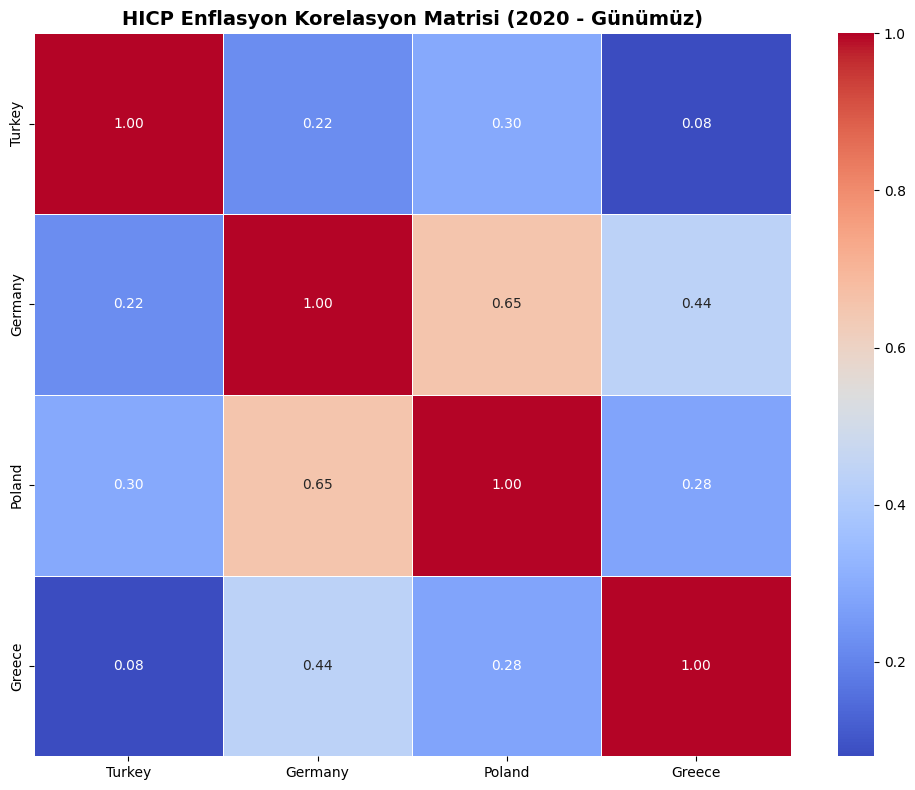

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Eksik verileri (varsa) son geçerli değerle doldurarak senkronizasyonu sağlıyoruz (Forward Fill)
df.fillna(method='ffill', inplace=True)

# Veri setindeki son 5 yılı filtreliyoruz (Makro trendleri daha net yakalamak için)
df_recent = df.loc['2020-01-01':'2025-12-31'] # Tüm ülkeleri ve ekstra feature'ları en zayıf halkanın (Türkiye) bittiği tarihte kırpıyoruz (Truncation)

# Korelasyon Matrisi: Türkiye enflasyonu hangi ülkeyle daha paralel hareket ediyor?
plt.figure(figsize=(10, 8))
sns.heatmap(df_recent.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('HICP Enflasyon Korelasyon Matrisi (2020 - Günümüz)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Hedef Değişken (Target): Türkiye'nin HICP'si
# Ancak biz bir sonraki ayı tahmin etmek istiyoruz. Bu yüzden 'y' değerini 1 ay yukarı kaydırıyoruz.
df_recent['Target_TR_HICP_Next_Month'] = df_recent['Turkey'].shift(-1)

# Son satırda Target NaN (Bilinmeyen gelecek ay) olacağı için o satırı eğitim verisinden düşürüyoruz
df_xgb = df_recent.dropna()

# X (Features) ve y (Target) tanımlaması
# Target sütunu hariç her şey modelin öğrenmesi için girdi (Input) olacak.
X = df_xgb.drop(columns=['Target_TR_HICP_Next_Month'])
y = df_xgb['Target_TR_HICP_Next_Month']

# Veriyi Train (Eğitim) ve Test olarak bölme (%80 Train, %20 Test)
# DİKKAT: Shuffle=False çok kritik! Zaman serilerinde veriyi rastgele karıştıramayız, kronolojiyi korumalıyız.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"✅ Training Data Shape: {X_train.shape}")
print(f"✅ Testing Data Shape: {X_test.shape}")

✅ Training Data Shape: (40, 4)
✅ Testing Data Shape: (10, 4)


/tmp/ipykernel_3507/3047451311.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_recent['Target_TR_HICP_Next_Month'] = df_recent['Turkey'].shift(-1)


In [8]:
# Pipeline'ın Ingestion ve Preprocessing fazı tamamlandı.
# Veriyi Model Training fazı için diske yazıyoruz (Export).
df_recent.to_csv('master_dataset_v1.csv')
print("✅ Veri başarıyla export edildi ve devir teslime hazır.")

✅ Veri başarıyla export edildi ve devir teslime hazır.
